In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def airrho(h, rho0=1.225, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km (8500 m) is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return ((1/(np.e**(h/H)))*rho0) #returns density in kg/m^3

In [26]:
#def airrhocm( h, rho0= 1.225/1000000, H = 850000, converttom = 'true'):
#    if converttom == 'false':
#        return ((1/(np.e**(h/H)))*rho0)
#    else:
#        return ((1/(np.e**(h/H)))*rho0)*1000000

In [3]:
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #two constants for bolide density based on possible composition

In [4]:
testlat = 3600 #three theoretical changes in latitude, longitude, and altitude
testlong = 2100 #units are all in meters
testalt = 40000

startalt = 80000 #80 km at start 80000 m

In [5]:
L = np.sqrt(testlat**2 + testlong**2 + testalt**2) #length of the column of air meters
sumrho=0

In [6]:
#delta = 1 meter

for i in range(testalt):
    rho = airrho(startalt-i) #calculate density for each meter the bolide passes through
    sumrho= sumrho+rho #sum each instance of density
    if i == testalt-1: #if it's the last loop...
        rimp = (L*sumrho**3)/rockyrho**4
        mimp = (L*sumrho**3)/metalrho**4
        print (f' If the bolide were rocky its radius would be {rimp} meters. If the bolide were high in metals its radius would be {mimp} meters.')

 If the bolide were rocky its radius would be 0.00021760583388477463 meters. If the bolide were high in metals its radius would be 1.0320426808046299e-05 meters.


In [7]:
sumrho=[]
step=[]

for i in range(testalt):
    rho = airrho(startalt-i) #calculate density for each meter the bolide passes through
    if i==0:
        sumrho.append(rho)
    else:
        sumrho.append(sumrho[i-1]+rho)
    step.append(i+1)

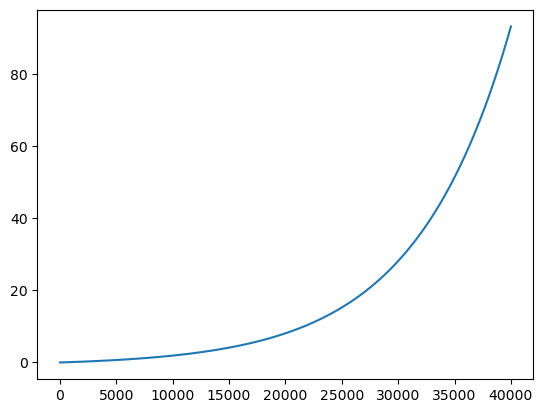

In [8]:
plt.plot(step,sumrho)

In [31]:
#delta = 10 cm

#sumrho2=[]
#step2=[]

#for i in range(testalt*100):
#    rho = airrhocm(startalt-(i/100)) #calculate density for each meter the bolide passes through
#    if i==0:
#        sumrho2.append(rho)
#    else:
#        sumrho2.append(sumrho2[i-1]+rho)
#    step2.append((i/100)+0.01)

In [32]:
#print(np.max(step), np.max(step2))

40000 40000.09


In [33]:
#print(np.max(sumrho), np.max(sumrho2))

93.29234436668328 4566464.323402618


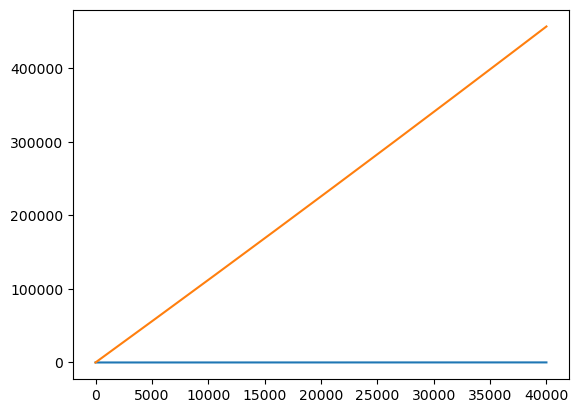

In [30]:
#plt.plot(step,sumrho)
#plt.plot(step2,sumrho2) #hmmmm

In [13]:
#trying with np.trapz. Very similar to summing the air density manually. Delta = meters

testintegrate=np.zeros(testalt)

for i in range(testalt):
    testintegrate[i] = airrho(startalt-i) #calculate density for each meter the bolide passes through
    if i == testalt-1: #if it's the last loop...
        rimp2 = (L*(np.trapz(testintegrate)**3))/rockyrho**4
        mimp2 = (L*(np.trapz(testintegrate)**3))/metalrho**4
        print (f' If the bolide were rocky its radius would be {rimp2} meters. If the bolide were high in metals its radius would be {mimp2} meters.')

 If the bolide were rocky its radius would be 0.00021756673668042002 meters. If the bolide were high in metals its radius would be 1.0318572538660513e-05 meters.


In [21]:
#delta = 10 cm

#testintegrate2=np.zeros(testalt*10)

#for i in range(testalt*10):
#    testintegrate2[i] = airrho(startalt-(i/10)) #calculate density for each meter the bolide passes through
#    if i == (testalt*10)-1: #if it's the last loop...
#        rimp3 = ((L*10)*np.trapz(testintegrate2)**3)/(rockyrho**4)
#        mimp3 = ((L*10)*np.trapz(testintegrate2)**3)/(metalrho**4)
#        print (f' If the bolide were rocky its radius would be {rimp3/10} meters. If the bolide were high in metals its radius would be {mimp3/10} meters.')

 If the bolide were rocky its radius would be 0.21763648717323497 meters. If the bolide were high in metals its radius would be 0.010321880606477773 meters.


In [22]:
#delta = 1 cm

#testintegrate3=np.zeros(testalt*100)

#for i in range(testalt*100):
#    testintegrate3[i] = airrho(startalt-(i/100)) #calculate density for each meter the bolide passes through
#    if i == (testalt*100)-1: #if it's the last loop...
#        rimp4 = ((L*100)*np.trapz(testintegrate3)**3)/(rockyrho**4)
#        mimp4 = ((L*100)*np.trapz(testintegrate3)**3)/(metalrho**4)
#        print (f' If the bolide were rocky its radius would be {rimp4/100} meters. If the bolide were high in metals its radius would be {mimp4/100} meters.')

 If the bolide were rocky its radius would be 217.64346351567698 meters. If the bolide were high in metals its radius would be 10.322211474590429 meters.


In [16]:
#np.trapz(testintegrate3)

9329.772160326163